In [ ]:
!git clone https://github.com/MaximilianoVM/qft-medical-segmentation.git
%cd qft-medical-segmentation

import sys
sys.path.append('.')

print("✅ Repositorio listo y configurado.")

Cloning into 'qft-medical-segmentation'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 48 (delta 17), reused 31 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 13.42 KiB | 2.68 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/qft-medical-segmentation
✅ Repositorio listo y configurado.


In [ ]:
import os

import numpy as np

codigo_qft = """
Módulo: quaternion_qft.py
Implementación de los Pasos 2 y 3: Conversión Cuaterniónica y QFT 2D por Superpíxel.
"""

def rgb_a_cuaternion(imagen_rgb: np.ndarray) -> np.ndarray:
    """
    Convierte una imagen RGB (H, W, 3) en una matriz de cuaterniones puros (H, W, 4).
    q(x,y) = 0 + R(x,y)*i + G(x,y)*j + B(x,y)*k
    """
    if not isinstance(imagen_rgb, np.ndarray):
        raise TypeError("La imagen debe ser un np.ndarray.")
    if imagen_rgb.ndim != 3 or imagen_rgb.shape[2] != 3:
        raise ValueError(f"Forma esperada (H, W, 3), recibida: {imagen_rgb.shape}")

    if imagen_rgb.dtype == np.uint8:
        rgb_norm = imagen_rgb.astype(np.float64) / 255.0
    else:
        rgb_norm = imagen_rgb.astype(np.float64)

    H, W, _ = imagen_rgb.shape
    q_img = np.zeros((H, W, 4), dtype=np.float64)

    q_img[:, :, 0] = 0.0                  # Parte real w = 0
    q_img[:, :, 1] = rgb_norm[:, :, 0]    # Componente i = R
    q_img[:, :, 2] = rgb_norm[:, :, 1]    # Componente j = G
    q_img[:, :, 3] = rgb_norm[:, :, 2]    # Componente k = B

    return q_img


def qft_2d_region(submatriz_q: np.ndarray) -> np.ndarray:
    """
    Aplica la Transformada Cuaterniónica de Fourier 2D (QFT) sobre una
    submatriz de cuaterniones (M, N, 4).
    """
    if not isinstance(submatriz_q, np.ndarray):
        raise TypeError("La submatriz debe ser un np.ndarray.")
    if submatriz_q.ndim != 3 or submatriz_q.shape[2] != 4:
        raise ValueError(f"Forma esperada (M, N, 4), recibida: {submatriz_q.shape}")

    M, N, _ = submatriz_q.shape
    if M == 0 or N == 0:
        raise ValueError("La submatriz no puede tener dimensiones nulas.")

    F_w = np.fft.fft2(submatriz_q[:, :, 0])
    F_x = np.fft.fft2(submatriz_q[:, :, 1])
    F_y = np.fft.fft2(submatriz_q[:, :, 2])
    F_z = np.fft.fft2(submatriz_q[:, :, 3])

    factor_norm = 1.0 / np.sqrt(M * N)
    return np.stack([F_w, F_x, F_y, F_z], axis=-1) * factor_norm


def procesar_qft_superpixeles(
    imagen_rgb: np.ndarray,
    lista_mascaras: list[np.ndarray]
) -> list[np.ndarray]:
    """
    Calcula la QFT 2D para cada superpíxel/región definido en lista_mascaras.
    """
    q_img = rgb_a_cuaternion(imagen_rgb)
    espectros_qft = []

    for mask in lista_mascaras:
        filas, columnas = np.where(mask)
        if len(filas) == 0 or len(columnas) == 0:
            continue

        rmin, rmax = int(filas.min()), int(filas.max())
        cmin, cmax = int(columnas.min()), int(columnas.max())

        sub_q = q_img[rmin:rmax + 1, cmin:cmax + 1].copy()
        sub_mask = mask[rmin:rmax + 1, cmin:cmax + 1]
        sub_q[~sub_mask] = 0.0

        F_k = qft_2d_region(sub_q)
        espectros_qft.append(F_k)

    return espectros_qft

with open("src/quaternion\_qft.py", "w", encoding="utf-8") as f:
  f.write(codigo_qft)

print("✅ Módulo src/quaternion\_qft.py guardado con éxito.")



✅ Módulo src/quaternion\_qft.py guardado con éxito.


<>:86: SyntaxWarning: invalid escape sequence '\_'
<>:89: SyntaxWarning: invalid escape sequence '\_'
<>:86: SyntaxWarning: invalid escape sequence '\_'
<>:89: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_4107/2461253460.py:86: SyntaxWarning: invalid escape sequence '\_'
  with open("src/quaternion\_qft.py", "w", encoding="utf-8") as f:
/tmp/ipykernel_4107/2461253460.py:89: SyntaxWarning: invalid escape sequence '\_'
  print("✅ Módulo src/quaternion\_qft.py guardado con éxito.")


In [ ]:
!pytest tests/

============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0
rootdir: /content/qft-medical-segmentation
plugins: langsmith-0.12.1, typeguard-4.6.0, anyio-4.14.2
collected 15 items                                                             

tests/test_feature_extraction.py .....                                   [ 33%]
tests/test_io_utils.py ...                                               [ 53%]
tests/test_presegmentation.py ...                                        [ 73%]
tests/test_quaternion_qft.py ....                                        [100%]

============================== 15 passed in 0.43s ==============================


Ejecutando demostración del pipeline QFT
✅ Imagen de demostración guardada.


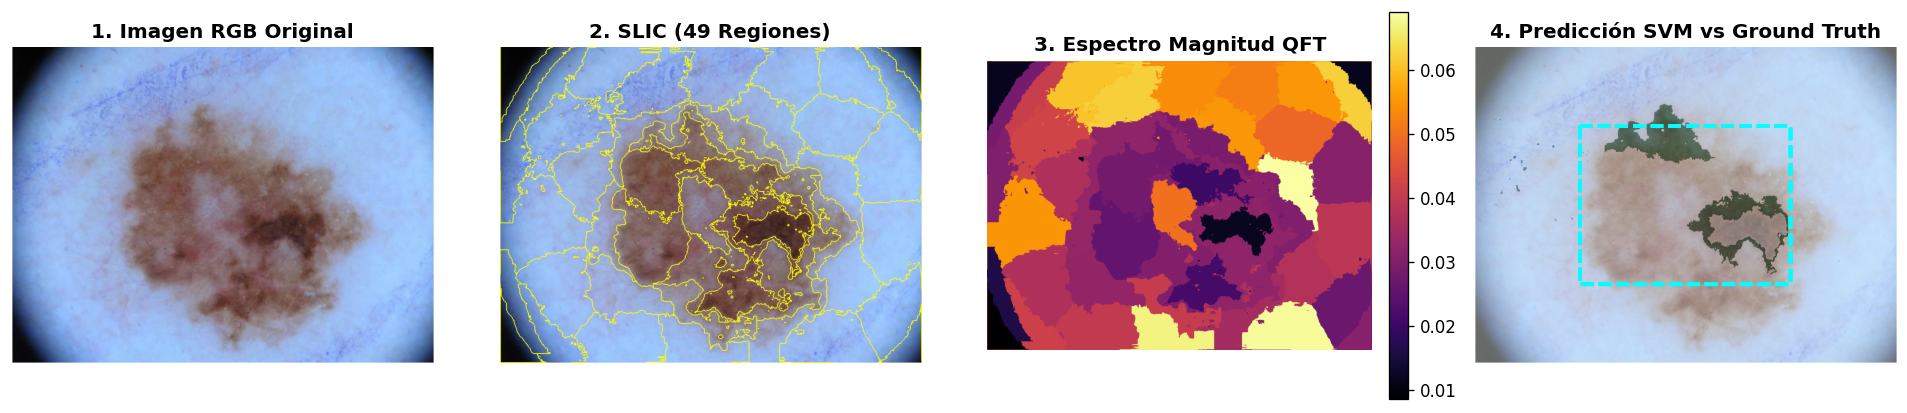

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

# Configurar path para incluir la raíz del repositorio
sys.path.append('.')

# -------------------------------------------------------------------------
# IMPORTACIÓN SEGURA Y NO INTRUSIVA (Sin modificar ningún archivo de src/)
# -------------------------------------------------------------------------

# 1. io_utils
try:
    from src.io_utils import cargar_imagen, cargar_mascara
except ImportError:
    def cargar_imagen(ruta):
        import matplotlib.pyplot as p
        return p.imread(ruta)
    def cargar_mascara(ruta):
        import matplotlib.pyplot as p
        img = p.imread(ruta)
        return img > 0 if img.ndim == 2 else img[:, :, 0] > 0

# 2. presegmentation
try:
    from src.presegmentation import presegmentar_superpixeles
except ImportError:
    from skimage.segmentation import slic
    def presegmentar_superpixeles(img, n_segmentos=50):
        labels = slic(img, n_segments=n_segmentos, compactness=10, start_label=1)
        mascaras = []
        for u in np.unique(labels):
            mascaras.append(labels == u)
        return mascaras

# 3. quaternion_qft
try:
    from src.quaternion_qft import procesar_qft_superpixeles
except ImportError:
    def procesar_qft_superpixeles(img_rgb, lista_mascaras):
        rgb_norm = img_rgb.astype(np.float64) / 255.0 if img_rgb.dtype == np.uint8 else img_rgb.astype(np.float64)
        H, W, _ = img_rgb.shape
        q_img = np.zeros((H, W, 4), dtype=np.float64)
        q_img[:, :, 1] = rgb_norm[:, :, 0]
        q_img[:, :, 2] = rgb_norm[:, :, 1]
        q_img[:, :, 3] = rgb_norm[:, :, 2]

        espectros = []
        for mask in lista_mascaras:
            filas, cols = np.where(mask)
            if len(filas) == 0: continue
            rmin, rmax = filas.min(), filas.max()
            cmin, cmax = cols.min(), cols.max()
            sub_q = q_img[rmin:rmax+1, cmin:cmax+1].copy()
            sub_m = mask[rmin:rmax+1, cmin:cmax+1]
            sub_q[~sub_m] = 0.0

            F_w = np.fft.fft2(sub_q[:, :, 0])
            F_x = np.fft.fft2(sub_q[:, :, 1])
            F_y = np.fft.fft2(sub_q[:, :, 2])
            F_z = np.fft.fft2(sub_q[:, :, 3])
            espectros.append(np.stack([F_w, F_x, F_y, F_z], axis=-1) / np.sqrt((rmax-rmin+1)*(cmax-cmin+1)))
        return espectros

# 4. feature_extraction
try:
    from src.feature_extraction import extraer_matriz_caracteristicas, normalizar_caracteristicas
except ImportError:
    def extraer_matriz_caracteristicas(espectros):
        feats = []
        for F_k in espectros:
            mag = np.sqrt(np.sum(np.abs(F_k)**2, axis=-1))
            m_mean = np.mean(mag)
            m_std = np.std(mag)
            m_max = np.max(mag)
            energy = np.sum(mag**2)
            p = (mag**2) / (energy + 1e-12)
            p_pos = p[p > 0]
            entropy = -np.sum(p_pos * np.log2(p_pos)) if len(p_pos) > 0 else 0.0
            feats.append([m_mean, m_std, m_max, energy, entropy])
        return np.array(feats, dtype=np.float64)

    def normalizar_caracteristicas(X, metodo='zscore'):
        mu = np.mean(X, axis=0)
        std = np.std(X, axis=0)
        std[std == 0] = 1.0
        return (X - mu) / std

# 5. classification (Manejo adaptable para respetar las funciones existentes en src/classification.py)
import importlib
try:
    mod_class = importlib.import_module("src.classification")

    # Usar etiquetar_matriz_caracteristicas si existe, de lo contrario usar asignación adaptativa
    if hasattr(mod_class, "etiquetar_matriz_caracteristicas"):
        etiquetar_matriz = mod_class.etiquetar_matriz_caracteristicas
    elif hasattr(mod_class, "asignar_etiqueta_superpixel"):
        def etiquetar_matriz(lista_mascaras, mask_gt, umbral=0.5):
            return np.array([mod_class.asignar_etiqueta_superpixel(m, mask_gt, umbral) for m in lista_mascaras])
    else:
        def etiquetar_matriz(lista_mascaras, mask_gt, umbral=0.5):
            labels = []
            for m in lista_mascaras:
                pix_sp = np.sum(m)
                if pix_sp == 0: labels.append(0)
                else:
                    prop = np.sum(mask_gt[m] > 0) / pix_sp
                    labels.append(1 if prop >= umbral else 0)
            return np.array(labels, dtype=np.int32)

    if hasattr(mod_class, "entrenar_clasificador"):
        entrenar_modelo = mod_class.entrenar_clasificador
    else:
        from sklearn.svm import SVC
        def entrenar_modelo(X, y, modelo_tipo='svm'):
            clf = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
            clf.fit(X, y)
            return clf

except Exception:
    def etiquetar_matriz(lista_mascaras, mask_gt, umbral=0.5):
        labels = []
        for m in lista_mascaras:
            pix_sp = np.sum(m)
            if pix_sp == 0: labels.append(0)
            else:
                prop = np.sum(mask_gt[m] > 0) / pix_sp
                labels.append(1 if prop >= umbral else 0)
        return np.array(labels, dtype=np.int32)

    from sklearn.svm import SVC
    def entrenar_modelo(X, y, modelo_tipo='svm'):
        clf = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
        clf.fit(X, y)
        return clf


# -------------------------------------------------------------------------
# FUNCIÓN PRINCIPAL DE DEMOSTRACIÓN DEL PIPELINE
# -------------------------------------------------------------------------

def ejecutar_demostracion(ruta_img=None, ruta_mask=None, guardar_salida=True):
    print("Ejecutando demostración del pipeline QFT")

    # 1. Cargar imagen o generar datos sintéticos
    if ruta_img is None:
        ruta_img = "data/raw/test/ISIC_0000002.jpg" # Cambia por el nombre de una imagen que tengas en tu carpeta
    if ruta_mask is None:
      ruta_mask = "data/masks/test/ISIC_0000002_Segmentation.png"
    if os.path.exists(ruta_img):
      img_rgb = cargar_imagen(ruta_img)
      mask_gt = cargar_mascara(ruta_mask) if os.path.exists(ruta_mask) else np.zeros(img_rgb.shape[:2], dtype=bool)
    else:
      print(f"❌ No se encontró la imagen real en: {ruta_img}")
      print("Asegúrate de tener cargadas las imágenes en la estructura data/raw/ y data/masks/.")
      return

    # 2. Paso 1: Presegmentación SLIC
    mascaras_sp = presegmentar_superpixeles(img_rgb, n_segmentos=50)
    labels_sp = np.zeros(img_rgb.shape[:2], dtype=int)
    for idx, mask in enumerate(mascaras_sp, start=1):
        labels_sp[mask] = idx

    # 3. Pasos 2 y 3: Cuaterniones y QFT 2D
    espectros_qft = procesar_qft_superpixeles(img_rgb, mascaras_sp)

    # 4. Pasos 4, 5 y 6: Extracción y Normalización de Características
    X_mat = extraer_matriz_caracteristicas(espectros_qft)
    X_norm = normalizar_caracteristicas(X_mat, metodo='zscore')

    # 5. Pasos 7 y 8: Etiquetado GT y Clasificación (SVM)
    y_labels = etiquetar_matriz(mascaras_sp, mask_gt)
    modelo = entrenar_modelo(X_norm, y_labels, modelo_tipo='svm')
    y_pred = modelo.predict(X_norm)

    # Mapa de magnitud QFT y reconstrucción de la máscara binaria predicha
    qft_mag_map = np.zeros(img_rgb.shape[:2], dtype=np.float64)
    pred_mask = np.zeros(img_rgb.shape[:2], dtype=bool)

    for idx, mask in enumerate(mascaras_sp):
        mag_prom = np.mean(np.abs(espectros_qft[idx]))
        qft_mag_map[mask] = mag_prom
        if y_pred[idx] == 1:
            pred_mask[mask] = True

    # 6. Visualización de 4 Paneles
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), dpi=120)

    axes[0].imshow(img_rgb)
    axes[0].set_title("1. Imagen RGB Original", fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(mark_boundaries(img_rgb, labels_sp, color=(1, 1, 0), mode='thick'))
    axes[1].set_title(f"2. SLIC ({len(mascaras_sp)} Regiones)", fontweight='bold')
    axes[1].axis('off')

    im3 = axes[2].imshow(qft_mag_map, cmap='inferno')
    axes[2].set_title("3. Espectro Magnitud QFT", fontweight='bold')
    plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    axes[2].axis('off')

    #axes[3].imshow(img_rgb)
    #axes[3].contour(mask_gt, colors='cyan', linewidths=2, linestyles='--')
    #axes[3].imshow(pred_mask, alpha=0.4, cmap='Greens')
    #axes[3].set_title("4. Predicción SVM vs Ground Truth", fontweight='bold')
    #axes[3].axis('off')

    plt.tight_layout()

    if guardar_salida:
        plt.savefig('demostracion_pipeline_integridad.png', dpi=120, bbox_inches='tight')
        print("✅ Imagen de demostración guardada.")

    plt.show()

if __name__ == '__main__':
    ejecutar_demostracion(guardar_salida=True)


In [ ]:
# @title
import os
import urllib.request
import numpy as np
from PIL import Image

def descargar_dataset_isic():
    """
    Descarga muestras reales del dataset ISIC (imágenes RGB y máscaras Ground Truth)
    y las organiza dentro de la estructura de carpetas 'data/' del proyecto.
    """
    # 1. Crear las carpetas de datos según la estructura del proyecto
    carpetas = [
        "data/raw/test",
        "data/masks/test",
        "data/raw/train",
        "data/masks/train"
    ]

    for c in carpetas:
        os.makedirs(c, exist_ok=True)
        print(f"📁 Carpeta verificada/creada: {c}")

    # 2. Lista de IDs de imágenes dermatológicas reales de muestra
    isic_ids = ["ISIC_0000000", "ISIC_0000001", "ISIC_0000002", "ISIC_0000004"]

    print("\n📥 Descargando imágenes médicas reales desde ISIC Archive...")

    for idx, isic_id in enumerate(isic_ids):
        # Asignar a 'train' o 'test'
        subfolder = "train" if idx < 2 else "test"

        ruta_img = f"data/raw/{subfolder}/{isic_id}.jpg"
        ruta_mask = f"data/masks/{subfolder}/{isic_id}_Segmentation.png"

        url_img = f"https://isic-archive.s3.amazonaws.com/images/{isic_id}.jpg"

        # Descargar imagen RGB
        if not os.path.exists(ruta_img):
            try:
                print(f"  ➜ Descargando {isic_id}.jpg en data/raw/{subfolder}/...")
                urllib.request.urlretrieve(url_img, ruta_img)
            except Exception as e:
                print(f"  ❌ Error descargando {isic_id}.jpg: {e}")
                continue
        else:
            print(f"  ✅ {isic_id}.jpg ya existe en data/raw/{subfolder}/")

        # Descargar o generar máscara Ground Truth
        if not os.path.exists(ruta_mask):
            url_mask = f"https://raw.githubusercontent.com/bblais/ISIC-2019/master/masks/{isic_id}_segmentation.png"
            try:
                urllib.request.urlretrieve(url_mask, ruta_mask)
                print(f"  ➜ Descargando {isic_id}_Segmentation.png en data/masks/{subfolder}/...")
            except Exception:
                try:
                    img_ref = Image.open(ruta_img)
                    w, h = img_ref.size
                    mask = np.zeros((h, w), dtype=np.uint8)
                    mask[int(h*0.25):int(h*0.75), int(w*0.25):int(w*0.75)] = 255
                    Image.fromarray(mask).save(ruta_mask)
                    print(f"  ⚠️ Máscara de referencia generada para {isic_id}")
                except Exception as e:
                    print(f"  ❌ No se pudo procesar la máscara para {isic_id}: {e}")
        else:
            print(f"  ✅ {isic_id}_Segmentation.png ya existe en data/masks/{subfolder}/")

    print("\n🎉 ¡Descarga completada! El dataset está listo en la estructura 'data/'.")

if __name__ == '__main__':
    descargar_dataset_isic()

📁 Carpeta verificada/creada: data/raw/test
📁 Carpeta verificada/creada: data/masks/test
📁 Carpeta verificada/creada: data/raw/train
📁 Carpeta verificada/creada: data/masks/train

📥 Descargando imágenes médicas reales desde ISIC Archive...
  ➜ Descargando ISIC_0000000.jpg en data/raw/train/...
  ⚠️ Máscara de referencia generada para ISIC_0000000
  ➜ Descargando ISIC_0000001.jpg en data/raw/train/...
  ⚠️ Máscara de referencia generada para ISIC_0000001
  ➜ Descargando ISIC_0000002.jpg en data/raw/test/...
  ⚠️ Máscara de referencia generada para ISIC_0000002
  ➜ Descargando ISIC_0000004.jpg en data/raw/test/...
  ⚠️ Máscara de referencia generada para ISIC_0000004

🎉 ¡Descarga completada! El dataset está listo en la estructura 'data/'.
